# Free size optimization of a pressure vessel 
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/meyer-nils/torch-fem/blob/main/examples/optimization/shell/pressure_vessel.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/meyer-nils/torch-fem/main?labpath=examples/optimization/shell/pressure_vessel.ipynb)

We redistribute a fixed amount of material over a thin-walled pressure vessel to make it as stiff as possible: each element's shell thickness is a design variable and we minimize compliance at constant material volume. 

The geometry is an octant of a vessel with a cylindrical barrel closed by a hemispherical dome. Membrane theory predicts what the optimizer should find: the barrel carries a hoop stress $\sigma_\theta = pr/t$ and an axial stress $\sigma_x = pr/2t$, while the dome carries only the equibiaxial stress $pr/2t$ - at equal thickness, the dome is overdesigned. We derive the optimal thickness ratio analytically below and compare it to the optimization result.

In [1]:
from math import sqrt

import matplotlib.pyplot as plt
import torch
from scipy.optimize import bisect
from tqdm import tqdm

from torchfem.data import get_data
from torchfem.io import import_shell
from torchfem.materials import IsotropicElasticityPlaneStress

torch.set_default_dtype(torch.float64)

## Model
We apply symmetry boundary conditions on the three symmetry planes and an internal pressure $p$ as consistent nodal forces along the element normals (see the [COPV example](../../basic/shell/copv.ipynb) for details).

In [2]:
# Aluminum-like isotropic material
mat = IsotropicElasticityPlaneStress(E=72000.0, nu=0.33)

# Import mesh (an octant of the vessel)
vessel = import_shell(get_data("copv.vtu"), material=mat, thickness=4.0)
nodes = vessel.nodes
elements = vessel.elements

# Symmetry boundary conditions (normal displacement and in-plane rotations)
for mask, dofs in [
    (nodes[:, 0] > -0.1, (0, 4, 5)),
    (nodes[:, 1] < 0.1, (1, 3, 5)),
    (nodes[:, 2] < 0.1, (2, 3, 4)),
]:
    for dof in dofs:
        vessel.constraints[mask, dof] = True

# Element areas, unit normals and centroids
v0, v1, v2 = nodes[elements[:, 0]], nodes[elements[:, 1]], nodes[elements[:, 2]]
normals = torch.linalg.cross(v1 - v0, v2 - v0)
areas = 0.5 * torch.linalg.norm(normals, dim=1)
normals = torch.nn.functional.normalize(normals, dim=1)
centroids = (v0 + v1 + v2) / 3.0

# Internal pressure as outward nodal forces: f = p * area / 3 along the normal
pressure = 1.0
nodal = torch.zeros_like(nodes)
for a in range(3):
    nodal.index_add_(0, elements[:, a], (pressure * areas / 3.0)[:, None] * normals)
vessel.forces[:, 0:3] = nodal

## Uniform reference design
The baseline design has a uniform thickness of 4. Its von Mises stress confirms the membrane picture: the barrel works at $\sqrt{3}$ times the stress of the dome.

In [3]:
# Solve the uniform design
u, f, sigma, _, _ = vessel.solve()

# Plane stress von Mises stress
mises = torch.sqrt(
    sigma[:, 0, 0] ** 2
    - sigma[:, 0, 0] * sigma[:, 1, 1]
    + sigma[:, 1, 1] ** 2
    + 3.0 * sigma[:, 0, 1] ** 2
)
vessel.plot(element_property={"von Mises stress": mises}, cmap="inferno", clim=[0, 25])

EmbeddableWidget(value='<iframe srcdoc="<!doctype html>\n<html lang=&quot;en&quot;>\n  <head>\n    <meta chars…

## Free size optimization
We minimize the compliance $C$ subject to a volume constraint

$$\min_{\mathbf{d}} \; C(\mathbf{d}) \quad \text{s.t.} \quad \sum_e t_e(\mathbf{d}) A_e = V_0, \quad d_{\min} \le d_e \le d_{\max},$$

where the physical element thicknesses $\mathbf{t} = \mathbf{W}\mathbf{d}$ are a filtered version of the design variables $\mathbf{d}$ using a linear hat filter $\mathbf{W}$ with a radius of 15 mm. The filter regularizes the design at the junction between dome and barrel, where local bending would otherwise cause a checkerboard-like pattern on this coarse mesh. Since the filter is just another differentiable operation in the computational graph, `torch.autograd` provides sensitivities that are consistent with the filtered design without any extra work.

The design update is an MMA-style method of moving asymptotes with an analytical solution of the separable dual problem.

In [4]:
# Linear hat filter
R = 15.0
dist = torch.cdist(centroids, centroids)
W = torch.clamp(R - dist, min=0.0)
W /= W.sum(dim=1, keepdim=True)

# Initial design, minimum design and maximum design
d_0 = 4.0 * torch.ones(vessel.n_elem, requires_grad=True)
d_min = 1.0 * torch.ones(vessel.n_elem)
d_max = 10.0 * torch.ones(vessel.n_elem)

# Volume gradient w.r.t. design variables and initial volume
dV = W.T @ areas
V_0 = torch.inner(d_0.detach(), areas)

# Lists for compliances, design variables and asymptotes
comp = []
d = [d_0]
L = []

# MMA parameter
s = 0.8

# Iterate solutions
for k in tqdm(range(20)):
    # Solve the problem with filtered thicknesses
    vessel.thickness = W @ d[k]
    u_k, f_k, _, _, _ = vessel.solve(differentiable_parameters=d[k])

    # Evaluation of compliance
    compliance = 0.5 * torch.inner(f_k.ravel(), u_k.ravel())

    # Compute sensitivity thanks to differentiable torchfem solver
    sensitivity = torch.autograd.grad(compliance, d[k])[0]

    # Compute asymptote
    if k <= 1:
        L_k = d[k] - s * (d_max - d_min)
    else:
        osc = (d[k] - d[k - 1]) * (d[k - 1] - d[k - 2]) < 0.0
        L_k = torch.where(
            osc,
            d[k] - s * (d[k - 1] - L[k - 1]),
            d[k] - 1 / sqrt(s) * (d[k - 1] - L[k - 1]),
        )
    L.append(L_k)

    # Compute lower move limit in this step
    d_min_k = torch.maximum(d_min, 0.9 * L[k] + 0.1 * d[k])

    # Analytical solution
    def d_star(mu):
        d_hat = L[k] + torch.sqrt((-sensitivity * (L[k] - d[k]) ** 2) / (mu * dV))
        return torch.maximum(torch.minimum(d_hat, d_max), d_min_k)

    # Analytical gradient
    def grad(mu):
        return torch.dot(d_star(mu), dV) - V_0

    # Solve dual problem with an adaptive upper bracket
    with torch.no_grad():
        mu_hi = 1.0
        while grad(mu_hi) > 0:
            mu_hi *= 10.0
        mu_star = bisect(grad, 1e-12, mu_hi)

    # Compute current optimal point with dual solution
    comp.append(compliance.detach())
    d.append(d_star(mu_star))

# Final filtered thickness distribution
d_opt = (W @ d[-1]).detach()
vessel.thickness = d_opt

100%|██████████| 20/20 [00:02<00:00,  6.75it/s]


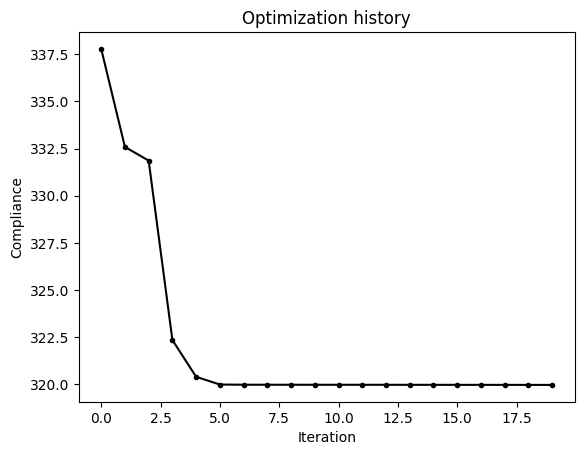

In [5]:
plt.plot(comp, ".-k")
plt.title("Optimization history")
plt.xlabel("Iteration")
plt.ylabel("Compliance")
plt.show()

## Comparison to membrane theory
At the optimum, all elements that are not at a bound must have the same compliance sensitivity per volume. For a statically determinate membrane, the stress resultants do not depend on the thickness and this condition means a *uniform strain energy density*

$$w = \frac{1}{2E}\left(\sigma_1^2 + \sigma_2^2 - 2\nu \sigma_1 \sigma_2\right).$$

Inserting the membrane stresses of barrel and dome, equal strain energy density requires

$$\kappa = \frac{t_d}{t_b} = \sqrt{\frac{1-\nu}{2\left(\frac{5}{4}-\nu\right)}} \approx 0.60$$

and the volume constraint fixes the absolute values via $t_b (A_b + \kappa A_d) = V_0$. The optimized thickness reproduces this prediction accurately in the membrane-dominated regions. Around the junction, the optimizer additionally reinforces the shell: the mismatch in radial expansion between barrel and dome causes local bending there, which membrane theory cannot capture.

Barrel thickness: 5.03 (membrane theory: 4.99)
Dome thickness:   3.01 (membrane theory: 3.01)
Thickness ratio:  0.598 (membrane theory: 0.603)


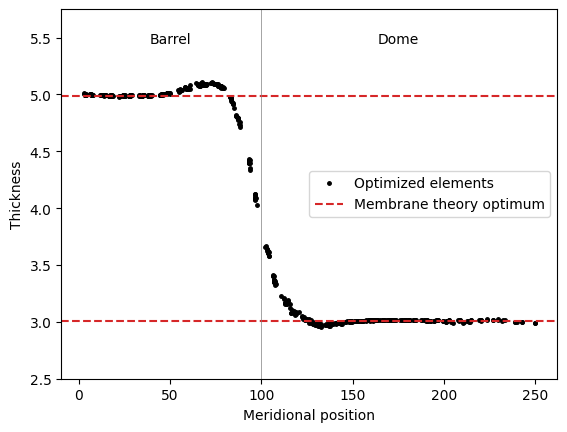

In [6]:
# Meridional position: distance from the barrel center (x=0) along the meridian
xc = centroids[:, 0]
rc = torch.sqrt(centroids[:, 1] ** 2 + centroids[:, 2] ** 2)
phi = torch.atan2(-(xc + 100.0), rc)
sm = torch.where(xc >= -100.0, -xc, 100.0 + 100.0 * phi)

# Analytical optimum from membrane theory
nu = 0.33
kappa = sqrt((1 - nu) / (2 * (5 / 4 - nu)))
A_b = areas[xc >= -100.0].sum()
A_d = areas[xc < -100.0].sum()
t_b = V_0 / (A_b + kappa * A_d)
t_d = kappa * t_b

# Mean optimized thickness in the membrane-dominated regions
barrel = (sm > 20.0) & (sm < 80.0)
dome = sm > 140.0
t_b_fem = (d_opt[barrel] * areas[barrel]).sum() / areas[barrel].sum()
t_d_fem = (d_opt[dome] * areas[dome]).sum() / areas[dome].sum()
print(f"Barrel thickness: {t_b_fem:.2f} (membrane theory: {t_b:.2f})")
print(f"Dome thickness:   {t_d_fem:.2f} (membrane theory: {t_d:.2f})")
print(f"Thickness ratio:  {t_d_fem / t_b_fem:.3f} (membrane theory: {kappa:.3f})")

plt.plot(sm, d_opt, ".k", markersize=5, label="Optimized elements")
plt.axhline(
    t_b.item(), color="tab:red", linestyle="--", label="Membrane theory optimum"
)
plt.axhline(t_d.item(), color="tab:red", linestyle="--")
plt.axvline(100.0, color="gray", linewidth=0.5)
plt.text(50.0, 5.45, "Barrel", ha="center")
plt.text(175.0, 5.45, "Dome", ha="center")
plt.ylim(2.5, 5.75)
plt.xlabel("Meridional position")
plt.ylabel("Thickness")
plt.legend()
plt.show()

## Optimized design
The optimized design shows a thick barrel, a thin dome and a reinforcement ring at the junction.

In [7]:
vessel.plot(element_property={"Thickness": d_opt}, thickness=True)

EmbeddableWidget(value='<iframe srcdoc="<!doctype html>\n<html lang=&quot;en&quot;>\n  <head>\n    <meta chars…